# Gene Expression ISP Analysis Tutorial

This tutorial demonstrates how to analyze In Silico Perturbation (ISP) results for **Gene Expression Prediction (GEP)**. Unlike embedding-based ISP, GEP ISP directly predicts how gene perturbations affect the expression of marker genes in epithelial cells.

## Overview

In this tutorial, you will learn how to:
1. Run GEP ISP simulations for target genes and background controls
2. Load and analyze GEP ISP results
3. Compare target gene perturbation against background distribution
4. Visualize the results with statistical annotations

## Marker Gene Set (SET1)

The SET1 marker genes used in this analysis are: SYP, CHGA, ENO2, NCAM1

## Prerequisites

Before running this notebook, you need to:
- Have the `TMEformer` package installed
- Have a trained GEP model
- Run the GEP ISP simulation scripts (see below)

### Step 0: Run GEP ISP Simulation

First, execute the GEP ISP simulation scripts to generate perturbation results:

```bash
# Target ISP: Perturb a specific gene (e.g., ASCL1)
tmeformer-gep-isp-target \
  --device 1 \
  --proj xenium \
  --model_ids GF_D1120_06 \
  --marker_set SET1 \
  --gene_mode single \
  --gene_list ASCL1 \
  --cell_ratio 5000 \
  --pred_cells internal

# Background ISP: Perturb random genes
tmeformer-gep-isp-target \
  --device 1 \
  --proj xenium_10X_ov \
  --model_ids GF_D1120_06 \
  --marker_set SET3 \
  --background 1 \
  --cell_ratio 10000 \
  --pred_cells internal
```


## Step 1: Setup and Data Loading

Import required libraries, configure the working directory, and load metadata.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from TMEformer.tme import TmeModeling_utils as tu
from TMEformer.tme import TmeModeling_utils_isp_gep as tu_isp_gep
from TMEformer.tme import TmeModeling_utils_isp_sim as tu_isp_sim

/home/liss/miniconda3/envs/geneformer_v3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Configure working directory and project
work_dir = "/dataSSD7T/liss/work/scPCa/model_paper/TMEformer-analysis/"
proj = "xenium"
isp_type = "target_rank"
pred_cells = "internal"

In [3]:
# Load cell metadata
obsmeta = pd.read_csv(work_dir + f"data/xenium/processed/xenium_obsmeta.csv")
obsmeta = obsmeta.rename(columns={"patch_2000": "patch_id"})

print(f"Loaded metadata with {len(obsmeta)} cells")
obsmeta.head()

Loaded metadata with 1495698 cells


,barcode,cell_id,sample_name,treat,treat2,Anno_01,spatial_1,spatial_2,n_genes_by_counts,total_counts,cell_type,tme_id,sample_id,patch_id
0,P005_aaaadolj-1,1,P005,P005_NT,NT,Stromal,19746.981458,16250.637695,294,447.0,Fibroblast,5,0,0_9_8
1,P005_aaaaghog-1,2,P005,P005_NT,NT,Stromal,19757.339490,16293.056641,190,223.0,Fibroblast,5,0,0_9_8
2,P005_aaaajnic-1,3,P005,P005_NT,NT,Stromal,19772.061231,16163.147705,441,722.0,Fibroblast,5,0,0_9_8
3,P005_aaaalmjd-1,4,P005,P005_NT,NT,T Cell,19782.952100,16050.635498,298,369.0,T_lymph,2,0,0_9_8
4,P005_aaaanlfi-1,5,P005,P005_NT,NT,Stromal,19764.207593,16153.165283,134,178.0,Fibroblast,5,0,0_9_8


In [4]:
# Load marker gene set
with open(work_dir + "isp_gene_exp/MODEL_FT_GENE_SET.json", "r") as f:
    FT_Multi_SETs = json.load(f)

set_id = "SET1"
model_gene_list = FT_Multi_SETs[set_id]
print(f"Marker genes for {set_id}: {model_gene_list}")

Marker genes for SET1: ['SYP', 'CHGA', 'ENO2', 'NCAM1']


## Step 2: Load and Process ISP Results

Configure the analysis task, select target and background conditions, and load ISP simulation results.

In [5]:
# Configure model IDs for analysis
model_color_map = {
    'black': ["GF_PR", "GF_CL", "GF_D0526_01"],
    '#7fc97f': ["GF_D1120_06"],
}
model_color_map = {v: k for k, v_list in model_color_map.items() for v in v_list}
model_ids = list(model_color_map.keys())
print(f"Model IDs: {model_ids}")

Model IDs: ['GF_PR', 'GF_CL', 'GF_D0526_01', 'GF_D1120_06']


In [6]:
# Summarize ISP simulation results
isp_dict, condi_meta = tu_isp_gep.summary_isp_gep_stat_files(
    task_dir=work_dir + f"isp_gene_exp/{proj}/output_isp/",
    set_id=set_id,
    isp_type=isp_type,
    pred_cells=pred_cells,
    model_ids=model_ids
)

print(f"Found {len(condi_meta)} conditions")

Found 564 conditions


In [7]:
# Define target and background conditions
if pred_cells == "internal":
    suffix = ""
else:
    suffix = f"_{pred_cells}"

conditions_dict = {
    "Target": [f"{set_id}{suffix}-Target_Rank-S5000-W100_EP1_KO0_KI0-ASCL1"],
    "Background": [f"{set_id}{suffix}-Target_Rank-S10000-W100_EP1_KO0_KI0-Background_C1"]
}

groups_ordered = [
    conditions_dict["Background"][0].split("-")[-1],
    conditions_dict["Target"][0].split("-")[-1]
]
print(f"Ordered groups: {groups_ordered}")

Ordered groups: ['Background_C1', 'ASCL1']


In [8]:
# Check model conditions (verify models have ISP results)
from collections import defaultdict

candi_model_ids = set([
    model_id for condi_list in conditions_dict.values() for condi in condi_list
    for model_id in isp_dict[condi]
])
candi_model_ids = sorted(candi_model_ids)

model_condi_counts = defaultdict(list)
for model_id in candi_model_ids:
    model_condi_counts["model_id"].append(model_id)
    for k, conditions in conditions_dict.items():
        model_condi_counts[k].append(
            sum([model_id in isp_dict[condition] for condition in conditions])
        )

pd.DataFrame(model_condi_counts)

,model_id,Target,Background
0,GF_CL,1,1
1,GF_D0526_01,1,1
2,GF_D1120_06,1,1
3,GF_PR,1,1


In [9]:
# Merge ISP results
stats_raw = tu_isp_gep.merge_isp_gep_stat_raw(
    proj, conditions_dict, model_ids, add_interval=False, work_dir=work_dir
)

# Merge with metadata to get sample and patch information
stats_raw = pd.merge(stats_raw, obsmeta[["cell_id", "sample_name", "patch_id"]])
stats_raw = stats_raw[
    ["model_id", "cell_id", "score_type", "score_method", "cell_score", "model_gene",
     "group", "isp_gene", "sample_name", "patch_id"]
]

print(f"Loaded {len(stats_raw)} records")
stats_raw.head()

Loaded 652224 records


,model_id,cell_id,score_type,score_method,cell_score,model_gene,group,isp_gene,sample_name,patch_id
0,GF_PR,46159,OE,area,0.455645,SYP,ASCL1,ASCL1,P005,0_11_9
1,GF_PR,46159,KD,area,-6.508705,SYP,ASCL1,ASCL1,P005,0_11_9
2,GF_PR,46159,OE,endpoint,-0.102939,SYP,ASCL1,ASCL1,P005,0_11_9
3,GF_PR,46159,KD,endpoint,-0.026928,SYP,ASCL1,ASCL1,P005,0_11_9
4,GF_PR,1468938,OE,area,4.263865,SYP,ASCL1,ASCL1,P024,7_5_7


In [12]:
# Filter and aggregate results at patch level
score_type = "OE"
score_method = "endpoint"
score_interval = None
stat_level = "patch"
stat_method = "mean"

stats_filt = tu_isp_gep.filter_isp_gep_stat_raw(
    stats_raw, score_type, score_method, score_interval,
    stat_level, stat_method, pair=True, z_score_col = "isp_gene"
)

print(f"Filtered to {len(stats_filt)} records")
stats_filt.head()

(77696, 8)
(1760, 7)
Filtered to 1760 records


,model_id,model_gene,patch_id,score_type,score_method,group,cell_score
1,GF_PR,CHGA,0_10_7,OE,endpoint,ASCL1,-0.117902
2,GF_PR,CHGA,0_10_7,OE,endpoint,Background_C1,0.001615
3,GF_PR,CHGA,0_10_8,OE,endpoint,ASCL1,-0.294514
4,GF_PR,CHGA,0_10_8,OE,endpoint,Background_C1,0.003728
7,GF_PR,CHGA,0_11_7,OE,endpoint,ASCL1,-0.403847


## Step 3: Statistical Analysis

Calculate summary statistics and p-values for each marker gene.

In [13]:
# Calculate p-values for each marker gene
stats_pval = []
for model_gene in stats_filt["model_gene"].unique():
    stats_pval_one = tu_isp_sim.calc_summary_stat_pvals(
        stats_filt[stats_filt["model_gene"] == model_gene],
        stat_level="patch", stat_method="mean",
        wilcoxon_test="less"
    )
    stats_pval_one.insert(1, "model_gene", model_gene)
    stats_pval.append(stats_pval_one)

stats_pval = pd.concat(stats_pval).reset_index(drop=True)
print("Statistical Summary:")
stats_pval

Statistical Summary:


,model_id,model_gene,Background_C1,ASCL1,p_value,log_p,log_p_cut
0,GF_PR,CHGA,-0.002868,0.092755,5.466887e-01,0.262260,0.262260
1,GF_CL,CHGA,-0.037456,1.666632,4.523704e-09,8.344506,8.344506
2,GF_D0526_01,CHGA,-0.048672,1.669512,2.135219e-09,8.670558,8.670558
3,GF_D1120_06,CHGA,-0.043833,1.525073,5.246896e-09,8.280098,8.280098
4,GF_PR,ENO2,0.009792,-0.546777,9.996217e-01,0.000164,0.000164
5,GF_CL,ENO2,-0.009011,0.403729,8.391175e-04,3.076177,3.076177
6,GF_D0526_01,ENO2,-0.009603,0.045850,3.516601e-02,1.453877,1.453877
7,GF_D1120_06,ENO2,-0.021986,0.349705,1.871908e-03,2.727716,2.727716
8,GF_PR,NCAM1,0.007311,-0.461964,9.978622e-01,0.000929,0.000929
9,GF_CL,NCAM1,-0.013336,0.613063,6.217823e-05,4.206362,4.206362


## Step 4: Visualization and Interpretation

Create a box plot with bar plot overlay to visualize the distribution of expression change scores between target and background perturbations.

In [14]:
# Select a specific model for visualization
model_id = "GF_D1120_06"
stats_filt_2 = stats_filt.query("model_id == @model_id")
print(f"Visualizing results for model: {model_id}")
stats_filt_2.head()

Visualizing results for model: GF_D1120_06


,model_id,model_gene,patch_id,score_type,score_method,group,cell_score
1969,GF_D1120_06,CHGA,0_10_7,OE,endpoint,ASCL1,0.066471
1970,GF_D1120_06,CHGA,0_10_7,OE,endpoint,Background_C1,-0.000911
1971,GF_D1120_06,CHGA,0_10_8,OE,endpoint,ASCL1,0.121553
1972,GF_D1120_06,CHGA,0_10_8,OE,endpoint,Background_C1,-0.001539
1975,GF_D1120_06,CHGA,0_11_7,OE,endpoint,ASCL1,0.651790


In [15]:
# Configure visualization parameters
palette_dict = {
    groups_ordered[0]: "grey",       # Background in grey
    groups_ordered[1]: "#ff7f0e",    # Target in orange
}

plot_params = {
    "x": "model_gene",
    "order": model_gene_list,
    "hue": "group",
    "hue_order": groups_ordered,
    "width": 0.5,
    "palette": palette_dict,
    "showfliers": True,
    "flierprops": dict(marker='o', markersize=1),
}

[(('SYP', 'Background_C1'), ('SYP', 'ASCL1')), (('CHGA', 'Background_C1'), ('CHGA', 'ASCL1')), (('ENO2', 'Background_C1'), ('ENO2', 'ASCL1')), (('NCAM1', 'Background_C1'), ('NCAM1', 'ASCL1'))]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

CHGA_Background_C1 vs. CHGA_ASCL1: Paired Wilcoxon test (one-sided), P_val:5.247e-09 Stat=8.700e+01
SYP_Background_C1 vs. SYP_ASCL1: Paired Wilcoxon test (one-sided), P_val:2.456e-08 Stat=1.190e+02
ENO2_Background_C1 vs. ENO2_ASCL1: Paired Wilcoxon test (one-sided), P_val:1.872e-03 Stat=4.240e+02
NCAM1_Background_C1 vs. NCAM1_ASCL1: Paired Wilcoxon test (one-sided), P_val:1.353e-06 Stat=2.100e+02


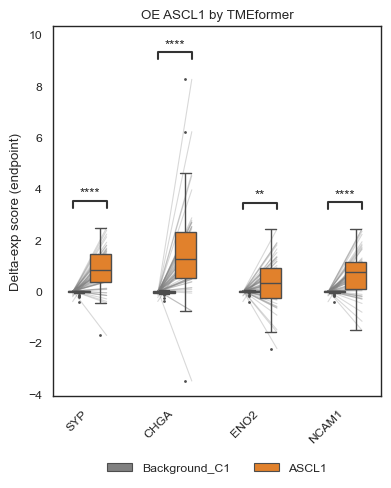

In [16]:
# Create the visualization
sns.set_theme(context='paper', style='white')

tu_isp_sim.vis_delta_emb_sim_boxbar(
    stats_filt_2,
    title_text=f"{score_type} {groups_ordered[1]} by TMEformer",
    ylabel_text=f"Delta-exp score ({score_method})",
    figsize=(4, 5),
    wilcoxon_test="less",
    line=True,
    line_params=None,
    pair_id_col="patch_id",
    **plot_params
)

plt.tight_layout()
plt.show()

## Interpretation

The plot shows the distribution of delta expression scores for each marker gene:
- **Background_C1**: Random gene perturbations (control)
- **ASCL1**: Target gene (ASCL1) overexpression

Key points to interpret:
1. **Higher scores** indicate greater predicted expression change for the marker gene
2. **Statistical significance** (p-value from one-sided Wilcoxon test) indicates whether ASCL1 perturbation has higher effect than random genes